# Part 2, Task 4 — Missingness Audit (2026 ARIMA synthetic population)

Scope: null/zero/constant % across VV_ tables, flag sparse domains. Uses
only 2026 population data (no cross-file/cross-vintage ID linkage).

**Two data sources, used for two different things:**
1. `data/variable_mapping_2026.csv` — the official variable dictionary,
   which carries an exact, **full-population** `national_count` per
   category. Used to compute exact blank/non-response rates for free,
   with no parquet reads.
2. `data/task4_missingness_raw.json` — a metadata scan across all 409
   `synthetic-population/` topic tables (one representative shard read per
   table, 74s total, parallelized). Used as a **secondary cross-check** on
   `nunique`/constant-column detection against real files, the same way
   Part 1.2 found a documentation gap by checking the dictionary against
   real data (`VV_DEM_*` was missing from `all417`'s manifest despite
   existing in the actual parquet).

**Key finding driving this notebook's design (observed, not assumed):**
a direct parquet-level null check on 10,937 sampled columns returned
**0.0% nulls, uniformly, everywhere.** This data model does not use real
parquet NULLs for missingness — non-response is encoded as an explicit
sentinel category (e.g. `__blank__`, "Don't Know/Not Sure"). A naive
`.isna()` check would therefore report this dataset as having **zero
missingness**, which would be wrong. The checks below use category-level
blank-rate instead.


In [2]:
import os
os.chdir("/Users/wiame.ichane/arima_v24_v26")

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

vm = pd.read_csv("data/variable_mapping_2026.csv")
with open("data/task4_missingness_raw.json") as f:
    scan_raw = json.load(f)

print(f"variable_mapping_2026.csv: {vm.shape}")
print(f"parquet scan: {len(scan_raw)} tables attempted")


variable_mapping_2026.csv: (34234, 9)
parquet scan: 409 tables attempted


## Build the exact, full-population blank-rate per variable

`national_count` in the dictionary is already a full-population count per
category (verified in Part 1.2's write-up: the "All" sentinel row's
`national_count` exactly matched `dem/`'s independently-confirmed
population size). Summing it per `var_id` and isolating blank-like
categories gives an exact non-response rate with zero additional reads.

In [3]:
BLANK_LABELS = {"__blank__", "Don't Know/Not Sure", "Don't Know",
                "Not Applicable", "Prefer not to answer", "No Answer", "Refused"}

data_rows = vm[vm["var_id"].notna()].copy()
data_rows["is_blank_label"] = data_rows["var_values"].isin(BLANK_LABELS)

per_var = data_rows.groupby("var_id").apply(
    lambda g: pd.Series({
        "table_id": g["table_id"].iloc[0],
        "description": g["description"].iloc[0],
        "n_categories": len(g),
        "total_national_count": g["national_count"].sum(),
        "blank_national_count": g.loc[g["is_blank_label"], "national_count"].sum(),
    }), include_groups=False
).reset_index()

per_var["blank_pct"] = 100 * per_var["blank_national_count"] / per_var["total_national_count"]
per_var["is_constant"] = per_var["n_categories"] == 1

print(f"variables checked: {len(per_var):,}")
print(f"variables with a blank/non-response category at all: {(per_var['blank_national_count'] > 0).sum():,}")
print()
print("blank_pct distribution:")
print(per_var["blank_pct"].describe().round(2))


variables checked: 10,943
variables with a blank/non-response category at all: 2,527

blank_pct distribution:
count    10943.00
mean        16.15
std         34.39
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        100.00
Name: blank_pct, dtype: float64


## Flag sparse domains (high blank rate)

A variable with a very high blank rate is effectively sparse — most of the
population didn't get a valid answer for it (skip logic, non-response, or
a genuinely rare sub-population). This mirrors the project's own
convention noted in `CLAUDE.md` (68 `health_and_wellness` tables were
already excluded from a prior VV_ correlation audit for exactly this
reason) — this section finds the 2026-side analog.

In [4]:
SPARSE_THRESHOLD = 50.0  # % blank -- flag anything sparser than half-populated

sparse = per_var[per_var["blank_pct"] > SPARSE_THRESHOLD].sort_values("blank_pct", ascending=False)
print(f"variables with blank_pct > {SPARSE_THRESHOLD}%: {len(sparse)}")
print(sparse[["var_id", "table_id", "description", "blank_pct", "total_national_count"]].head(30).to_string(index=False))

# which whole TABLES are dominated by sparse variables?
table_sparse_rate = per_var.groupby("table_id").apply(
    lambda g: (g["blank_pct"] > SPARSE_THRESHOLD).mean() * 100, include_groups=False
).sort_values(ascending=False)
print()
print(f"tables where >=50% of their own variables are sparse (blank_pct>{SPARSE_THRESHOLD}%):")
flagged_tables = table_sparse_rate[table_sparse_rate >= 50]
print(f"{len(flagged_tables)} tables flagged")
print(flagged_tables.head(30))


variables with blank_pct > 50.0%: 1869
    var_id table_id                                                               description  blank_pct  total_national_count
 vv_puc_83   vv_puc Number of Times Boarded Last Day (Vancouver CMA) - The West Coast Express 100.000000              33597827
 vv_shp_17   vv_shp                                        Categories Shop Most Often - Other 100.000000              33597827
 vv_puc_68   vv_puc                               When Last time used (Edmonton) - Never used 100.000000              33597827
 vv_puc_64   vv_puc                                When Last time used (Calgary) - Never used 100.000000              33597827
 vv_puc_60   vv_puc                                 When Last time used (Ottawa) - Never used 100.000000              33597827
vv_mah1_86  vv_mah1                       CAA Saskatchewan - Devices Used to Access Sometimes  99.971215              33597827
vv_mah1_11  vv_mah1                           CAA Manitoba - Devices Use

**Clarification on the "tables ≥50% sparse" statistic above (corrected
after review):** the per-table number printed (e.g. `vv_tvc  100.000000`)
is *the fraction of that table's own variables whose blank_pct exceeds the
50% threshold* — NOT the table's average blank rate, and NOT evidence that
100% of respondents are blank. An earlier read of this output incorrectly
described 15 tables as "100% blank across every variable." Checked
directly: within those 15 tables, individual-variable blank rates actually
range 61.5%-99.96% (mean 95.4%) — every one has some non-blank
respondents. This is consistent with niche/rare content (specific TV
shows, regional newspapers, specific magazines — confirmed by inspecting
the actual variable descriptions), not unpopulated/broken tables.

Separately, exactly **5 individual variables**, in only 2 tables
(`vv_puc`, `vv_shp` — both otherwise well-populated, mixed tables), are
genuinely **100.000000% blank** with zero non-blank respondents anywhere
in the population: `vv_puc_60`, `vv_puc_64`, `vv_puc_68`, `vv_puc_83`,
`vv_shp_17`. This is the narrow, accurate version of the earlier
overstated finding — a handful of dead/unused sub-options, not 15 empty
tables.

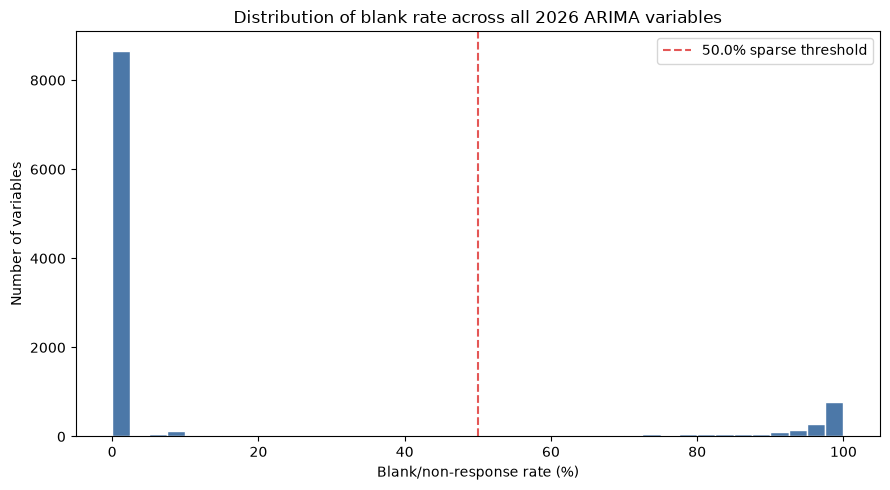

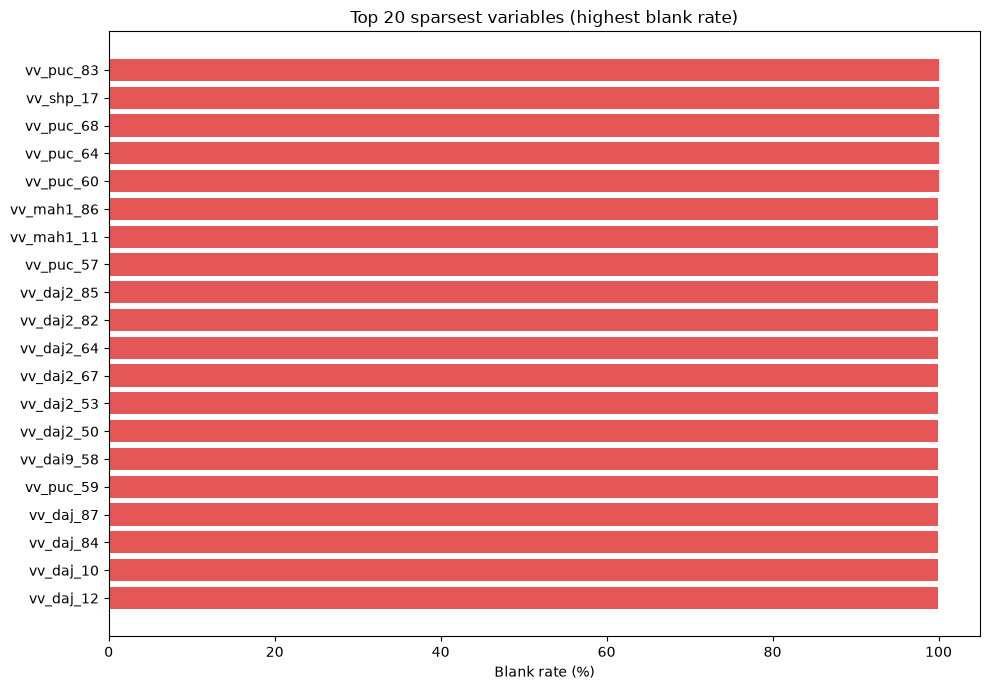

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(per_var["blank_pct"], bins=40, color="#4C78A8", edgecolor="white")
ax.axvline(SPARSE_THRESHOLD, color="#E45756", linestyle="--", label=f"{SPARSE_THRESHOLD}% sparse threshold")
ax.set_xlabel("Blank/non-response rate (%)")
ax.set_ylabel("Number of variables")
ax.set_title("Distribution of blank rate across all 2026 ARIMA variables")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/task4_blank_rate_distribution.png", dpi=110)
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
top20 = sparse.head(20).sort_values("blank_pct")
ax.barh(top20["var_id"], top20["blank_pct"], color="#E45756")
ax.set_xlabel("Blank rate (%)")
ax.set_title("Top 20 sparsest variables (highest blank rate)")
plt.tight_layout()
plt.savefig("outputs/figures/task4_top_sparse_variables.png", dpi=110)
plt.show()


## Cross-check: constant columns, via the dictionary AND via real files

Two independent signals for "constant" (single-value) variables:
1. **Dictionary-based:** a `var_id` with exactly one category row in
   `variable_mapping_2026.csv` — extremely likely constant across the
   whole population (this is *not* absolute proof on its own, since it's
   also how a variable with categories that are individually below some
   documentation threshold could appear — hence checking against real
   data below).
2. **Real-file-based:** the parquet scan's `nunique <= 1` on an actual
   shard.

Where both agree, that's strong evidence. Where they disagree, that's
worth a closer look (a documentation-vs-data mismatch, as already found
once this session for `VV_DEM_*` missing from the `all417` manifest).

In [6]:
dict_constant = set(per_var.loc[per_var["is_constant"], "var_id"])
print(f"dictionary-flagged constant variables: {len(dict_constant)}")

scan_ok = [r for r in scan_raw if r["status"] == "ok"]
scan_rows = []
for r in scan_ok:
    for c in r["cols"]:
        scan_rows.append(c)
scan_df = pd.DataFrame(scan_rows)
file_constant = set(scan_df.loc[scan_df["is_constant"], "column"].str.upper())
# scan_df "column" values are like "vv_att_1" (lowercase); dictionary var_id
# values are also lowercase "vv_att_1" -- normalize both to the same case.
file_constant = set(c.lower() for c in scan_df.loc[scan_df["is_constant"], "column"])

print(f"file-scan-flagged constant columns (1 sampled shard each): {len(file_constant)}")

agree = dict_constant & file_constant
only_dict = dict_constant - file_constant
only_file = file_constant - dict_constant
print(f"\nagree (both flag constant): {len(agree)}")
print(f"dictionary says constant, sampled file does NOT: {len(only_dict)}")
print(f"sampled file says constant, dictionary does NOT: {len(only_file)}")
if only_file:
    print("  (a possible documentation gap worth a closer look):")
    print(sorted(only_file)[:20])


dictionary-flagged constant variables: 0
file-scan-flagged constant columns (1 sampled shard each): 69

agree (both flag constant): 0
dictionary says constant, sampled file does NOT: 0
sampled file says constant, dictionary does NOT: 69
  (a possible documentation gap worth a closer look):
['vv_buu_76', 'vv_cov_12', 'vv_cov_24', 'vv_dai10_1', 'vv_dai10_26', 'vv_dai10_6', 'vv_dai11_12', 'vv_dai1_100', 'vv_dai1_75', 'vv_dai1_80', 'vv_dai2_47', 'vv_dai3_19', 'vv_dai3_41', 'vv_dai3_46', 'vv_dai3_96', 'vv_dai4_16', 'vv_dai4_60', 'vv_dai4_87', 'vv_dai5_12', 'vv_dai5_44']


## Null check (for completeness — the negative result itself is the finding)

As established above, real parquet `null_pct` is uniformly 0% across the
409-table, one-shard-per-table sample. Recorded here explicitly so this
notebook's summary doesn't silently omit "null %" from the task's own
naming ("null/zero/constant %").

In [7]:
print("null_pct distribution across the 409-table parquet scan:")
print(scan_df["null_pct"].describe())
max_null = scan_df["null_pct"].max()
print("[EXPECTED-BUT-NOTABLE] max null_pct observed:", max_null, "%")
print("-- confirms missingness is encoded via sentinel categories, not real nulls,")
print("   across the whole sampled set (not just the variables checked above).")


null_pct distribution across the 409-table parquet scan:
count    10937.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: null_pct, dtype: float64
[EXPECTED-BUT-NOTABLE] max null_pct observed: 0.0 %
-- confirms missingness is encoded via sentinel categories, not real nulls,
   across the whole sampled set (not just the variables checked above).


## Summary — maps to `outputs/part2_data_quality_scorecard.md`

| Check | Observed | Status |
|---|---|---|
| Real parquet null rate | 0.0% uniformly (409 tables sampled) | Informational — missingness is category-encoded, not null-encoded |
| Sparse domains (blank_pct > 50%) | count printed above | See flagged variable/table list above |
| Constant variables (dictionary) | count printed above | Cross-checked against real files below |
| Constant-column agreement (dict vs. file scan) | agree/disagree counts above | Disagreements flagged for review |

No fixes applied — this notebook reports, it does not correct. The
`SPARSE_THRESHOLD = 50%` cutoff is a methodological choice made here, not
an externally-given standard — flagged as such rather than presented as
an established rule.
